In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
x = np.array((1,2,5))
y = np.array((5,9,8))
print(type(x))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


# Euclidean Distance (L2 Norm or Ridge Regression)

In [10]:
# Using Mathematics
x = np.array((1,2,5))
y = np.array((5,9,8))
eu = np.sqrt(np.sum(np.square(x-y)))
eu

8.602325267042627

In [9]:
# Using scikit-learn
from sklearn.metrics.pairwise import euclidean_distances
x = np.array(([[1,2,5]]))
y = np.array(([[5,9,8]]))
eu = euclidean_distances(x,y)
eu

array([[8.60232527]])

# Manhatten Distance (l1 Norm or Lasso Regression)

In [17]:
# Using Mathematics
x = np.array(([[1,2,5]]))
y = np.array(([[5,9,8]]))
md1 = np.sum(np.abs(x-y))
md1

14

In [18]:
# Using scikit-learn
from sklearn.metrics.pairwise import manhattan_distances
x = np.array(([[1,2,5]]))
y = np.array(([[5,9,8]]))
md2 = manhattan_distances(x,y)
md2

array([[14.]])

In [20]:
# Import Dataset
df = pd.read_csv('supershops.csv')
df.head()

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.10,Dhaka,192261.83
1,162597.70,151377.59,443898.53,Ctg,191792.06
2,153441.51,101145.55,407934.54,Rangpur,191050.39
3,144372.41,118671.85,383199.62,Dhaka,182901.99
4,142107.34,91391.77,366168.42,Rangpur,166187.94


# Visualization

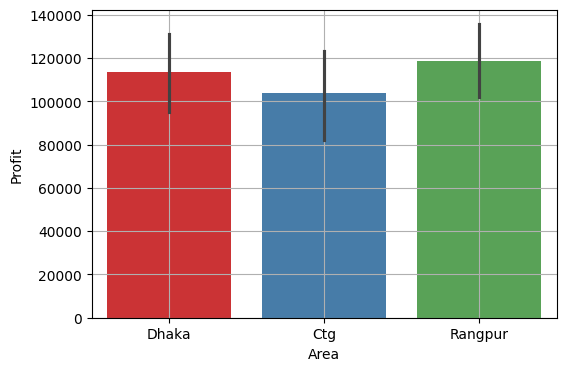

In [26]:
plt.figure(figsize=(6,4))
#plt.bar(df.Area, df.Profit)
sns.barplot(x = df.Area, y = df.Profit, palette = 'Set1' , hue = df.Area)
plt.grid()
plt.show()

# Normalization

## MinMax Scaling

In [69]:
from sklearn.preprocessing import MinMaxScaler
mmx = MinMaxScaler(feature_range=(0, 1))
mmx

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [62]:
df1 = df.copy()
df2 = df.copy()
df3 = df.copy()
df4 = df.copy()
df5 = df.copy()

In [63]:
df1.head()

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.10,Dhaka,192261.83
1,162597.70,151377.59,443898.53,Ctg,191792.06
2,153441.51,101145.55,407934.54,Rangpur,191050.39
3,144372.41,118671.85,383199.62,Dhaka,182901.99
4,142107.34,91391.77,366168.42,Rangpur,166187.94


In [64]:
x = df1.iloc[:,0:4]
y = df.iloc[:,-1]

In [65]:
x.head()

,Marketing Spend,Administration,Transport,Area
0,114523.61,136897.80,471784.10,Dhaka
1,162597.70,151377.59,443898.53,Ctg
2,153441.51,101145.55,407934.54,Rangpur
3,144372.41,118671.85,383199.62,Dhaka
4,142107.34,91391.77,366168.42,Rangpur


In [66]:
y.head()

0    192261.83
1    191792.06
2    191050.39
3    182901.99
4    166187.94
Name: Profit, dtype: float64

In [67]:
print(x.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Marketing Spend  50 non-null     float64
 1   Administration   50 non-null     float64
 2   Transport        49 non-null     float64
 3   Area             50 non-null     object 
dtypes: float64(3), object(1)
memory usage: 1.7+ KB
None


In [68]:
for col in x.columns:
    if x[col].dtype == 'object':
        continue
    x[col] = mmx.fit_transform(x[[col]])
x.head()

,Marketing Spend,Administration,Transport,Area
0,0.692617,0.651744,1.000000,Dhaka
1,0.983359,0.761972,0.940893,Ctg
2,0.927985,0.379579,0.864664,Rangpur
3,0.873136,0.512998,0.812235,Dhaka
4,0.859438,0.305328,0.776136,Rangpur
